C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18548\1262500892.py:7: DeprecationWarning: Importing display from IPython.core.display is deprecated since IPython 7.14, please import from IPython display
  from IPython.core.display import display
[*********************100%***********************]  1 of 1 completed
C:\Users\ADMIN\anaconda3\Lib\site-packages\mplfinance\_arg_validators.py:84: UserWarning: 


            POSSIBLE TO SEE DETAILS (Candles, Ohlc-Bars, Etc.)
   For more information see:
   - https://github.com/matplotlib/mplfinance/wiki/Plotting-Too-Much-Data
   
   TO SILENCE THIS WARNING, set `type='line'` in `mpf.plot()`
   OR set kwarg `warn_too_much_data=N` where N is an integer 
   LARGER than the number of data points you want to plot.

  warnings.warn('\n\n ================================================================= '+


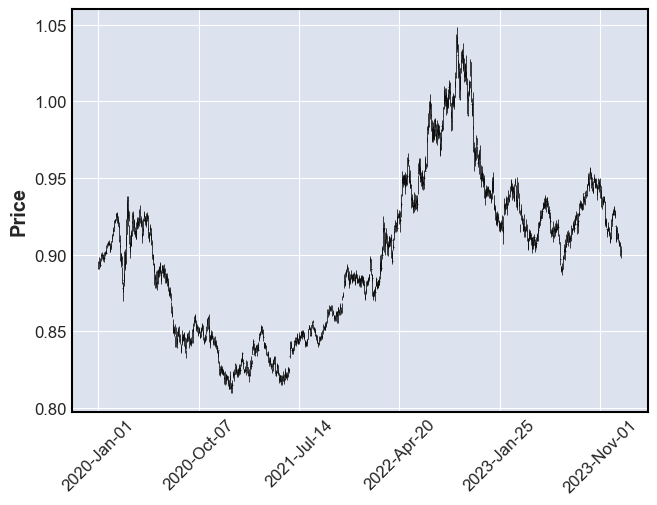

In [1]:
import datetime
import numpy as np
import pandas as pd
import mplfinance as mpf  # Use mplfinance instead of matplotlib.finance
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.core.display import display
%matplotlib inline

# time period
d1 = datetime.datetime(2020, 1, 1)
d2 = datetime.datetime(2023, 12, 31)

# Fetching data from yahoo finance
# List of Symbols : http://finance.yahoo.com/webservice/v1/symbols/allcurrencies/quote
# Use the yfinance library to fetch data as quotes_historical_yahoo_ochl is deprecated

import yfinance as yf
data = yf.download('EUR=X', start=d1, end=d2)

# If you want to use mplfinance to plot the data:
mpf.plot(data)

In [2]:
data.head()

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-01,0.89120,0.89610,0.8906,0.891200,0.891200,0
2020-01-02,0.89135,0.89551,0.8907,0.891200,0.891200,0
2020-01-03,0.89519,0.89882,0.8944,0.895140,0.895140,0
2020-01-06,0.89586,0.89621,0.8922,0.895900,0.895900,0
2020-01-07,0.89319,0.89808,0.8929,0.893017,0.893017,0


In [20]:
df.to_csv('eurusd.csv', index=False)

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18548\3690575279.py:4: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df[['Open','High','Low','Close','Adj Close']] = df[['Open','High','Low','Close','Adj Close']].applymap(lambda x: 1.0/x)


,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2020-01-01,1.122083,1.115947,1.122839,1.122083,1.122083,0
2020-01-02,1.121894,1.116682,1.122712,1.122083,1.122083,0
2020-01-03,1.117081,1.112570,1.118068,1.117144,1.117144,0
2020-01-06,1.116246,1.115810,1.120825,1.116196,1.116196,0
2020-01-07,1.119583,1.113487,1.119946,1.119800,1.119800,0


<Axes: xlabel='Date'>

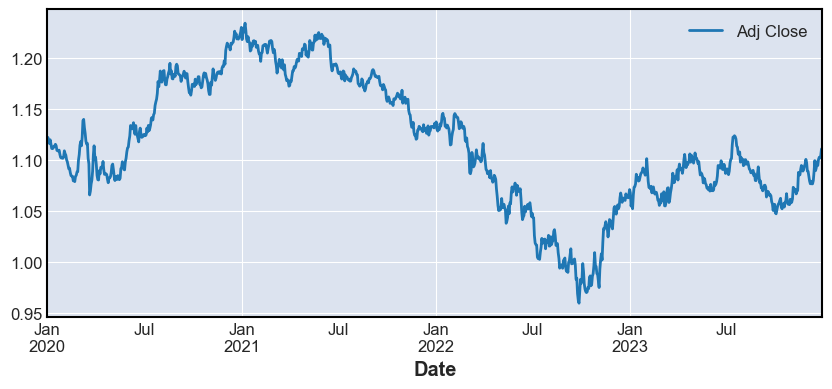

In [3]:
# Conveert data into Pandas Dataframe
df = pd.DataFrame(data)
# df.drop(['year','month','day','d'], inplace=True, axis=1)
df[['Open','High','Low','Close','Adj Close']] = df[['Open','High','Low','Close','Adj Close']].applymap(lambda x: 1.0/x)
display(df.head())

# Reset the index to make 'Date' a column
df = df.reset_index()  # This line is added

df.plot(x='Date', y='Adj Close', figsize=(10,4))

In [4]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2020-01-01,1.122083,1.115947,1.122839,1.122083,1.122083,0
1,2020-01-02,1.121894,1.116682,1.122712,1.122083,1.122083,0
2,2020-01-03,1.117081,1.112570,1.118068,1.117144,1.117144,0
3,2020-01-06,1.116246,1.115810,1.120825,1.116196,1.116196,0
4,2020-01-07,1.119583,1.113487,1.119946,1.119800,1.119800,0


<Axes: xlabel='Date'>

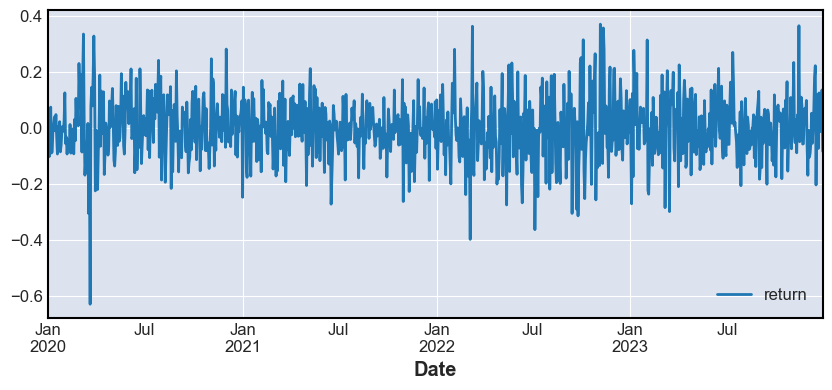

In [5]:
# Normalize aclose value
# We use this value to train model

df['return'] = df['Adj Close'] - df['Adj Close'].shift(1)
return_range = df['return'].max() - df['return'].min()
df['return'] = df['return'] / return_range

df.plot(x='Date', y='return', figsize=(10,4))

In [6]:
# Make label, 1 as rising price, 0 as falling price

df['label'] = df['return'].shift(-1)
df['label'] = df['label'].apply(lambda x: 1 if x>0.0 else 0)
df.dropna(inplace=True)
df.tail()

,Date,Open,High,Low,Close,Adj Close,Volume,return,label
1038,2023-12-25,1.102657,1.099989,1.104240,1.102657,1.102657,0,0.042179,0
1039,2023-12-26,1.102026,1.100958,1.103996,1.102026,1.102026,0,-0.013072,1
1040,2023-12-27,1.104301,1.102925,1.112248,1.104301,1.104301,0,0.047079,1
1041,2023-12-28,1.110864,1.107101,1.113945,1.110864,1.110864,0,0.135772,0
1042,2023-12-29,1.106819,1.104326,1.108647,1.106819,1.106819,0,-0.083684,0


In [7]:
# Make training dataset

n_features = 60 # number of features

train_x = np.array([]).reshape([-1,n_features])
train_y = np.array([]).reshape([-1,1])
for index, row in df.iterrows():
    i = df.index.get_loc(index)
    if i<n_features:
        continue

    _x = np.array(df[i-n_features+1:i+1]['return']).T.reshape([1, -1])
    _y = df.iloc[i]['label'] # Use .iloc for positional indexing
    train_x = np.vstack((train_x, _x))
    train_y = np.vstack((train_y, _y))
train_y = train_y.reshape([-1])
print(train_x.shape)
print(train_y.shape)
print('%% of Class0 : %f' % (np.count_nonzero(train_y == 0)/float(len(train_y))))
print('%% of Class1 : %f' % (np.count_nonzero(train_y == 1)/float(len(train_y))))

(982, 60)
(982,)
% of Class0 : 0.501018
% of Class1 : 0.498982


In [22]:
# Define Model and fit
# Here we use 95% of data for training, and last 5% for testing

from sklearn.ensemble import GradientBoostingClassifier
model = GradientBoostingClassifier(random_state=0, learning_rate=0.0001, n_estimators=10000)

print("--- checkpoint 1 ---")
train_len = int(len(train_x)*0.95)
model.fit(train_x[:train_len], train_y[:train_len])
print("--- checkpoint 2 ---")
accuracy = model.score(train_x[train_len:], train_y[train_len:])
print('Testing Accuracy: %f' % accuracy)

--- checkpoint 1 ---
--- checkpoint 2 ---
Testing Accuracy: 0.640000


In [21]:
from sklearn.ensemble import GradientBoostingClassifier as GBClassifier
from sklearn.metrics import accuracy_score
import numpy as np  # Assuming numpy is being used for handling data


# Define the model with different learning rates
learning_rates = [0.001, 0.01, 0.0005, 0.0001, 0.0002, 0.0003, 0.0004, 0.02, 0.03, 0.04, 0.05, 0.002, 0.003, 0.004, 0.005, 0.006, 0.007, 0.008, 0.009]

# Ensure the data length is sufficient for splitting
if len(train_x) < 2:
    raise ValueError("Training data is too small to be split.")

train_len = int(len(train_x) * 0.95)
test_len = len(train_x) - train_len

# Ensure train_len and test_len are correctly calculated
if train_len == 0 or test_len == 0:
    raise ValueError("Insufficient data for training and testing split.")

for lr in learning_rates:
    clf = GBClassifier(random_state=0, learning_rate=lr, n_estimators=10000)

    # Fit the model on the training data
    clf.fit(train_x[:train_len], train_y[:train_len])

    # Calculate accuracy on the test data
    y_pred = clf.predict(train_x[train_len:])
    y_test = train_y[train_len:]
    accuracy = accuracy_score(y_test, y_pred)
    clf_score = clf.score(train_x[train_len:], train_y[train_len:])
    print(f'Learning Rate: {lr}, Testing Accuracy: {accuracy:.4f}, clf_score: {clf_score}')

print('Code execution is over')


Learning Rate: 0.001, Testing Accuracy: 0.5200, clf_score: 0.52
Learning Rate: 0.01, Testing Accuracy: 0.4200, clf_score: 0.42
Learning Rate: 0.0005, Testing Accuracy: 0.5200, clf_score: 0.52
Learning Rate: 0.0001, Testing Accuracy: 0.6400, clf_score: 0.64
Learning Rate: 0.0002, Testing Accuracy: 0.5800, clf_score: 0.58
Learning Rate: 0.0003, Testing Accuracy: 0.5600, clf_score: 0.56
Learning Rate: 0.0004, Testing Accuracy: 0.5400, clf_score: 0.54
Learning Rate: 0.02, Testing Accuracy: 0.4400, clf_score: 0.44
Learning Rate: 0.03, Testing Accuracy: 0.4200, clf_score: 0.42
Learning Rate: 0.04, Testing Accuracy: 0.4600, clf_score: 0.46
Learning Rate: 0.05, Testing Accuracy: 0.4400, clf_score: 0.44
Learning Rate: 0.002, Testing Accuracy: 0.4200, clf_score: 0.42
Learning Rate: 0.003, Testing Accuracy: 0.4400, clf_score: 0.44
Learning Rate: 0.004, Testing Accuracy: 0.4600, clf_score: 0.46
Learning Rate: 0.005, Testing Accuracy: 0.4600, clf_score: 0.46
Learning Rate: 0.006, Testing Accuracy: 

,return,label,pred,won,pnl,equity
44,0.002039,1.0,1.0,True,203.887678,6220.576093
45,-0.000632,0.0,0.0,True,63.187042,6283.763135
46,0.002276,1.0,1.0,True,227.570194,6511.333329
47,0.006563,1.0,0.0,False,-656.299119,5855.034210
48,-0.004045,0.0,0.0,True,404.513678,6259.547888


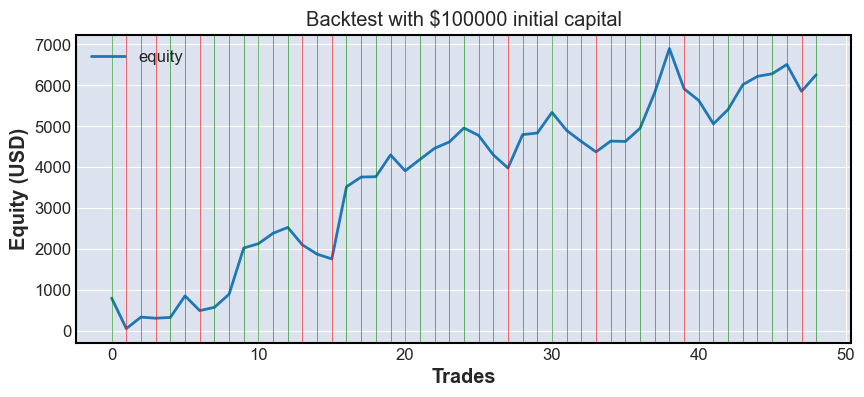

In [23]:
# Predict test data

pred = model.predict(train_x[train_len:])


# Calculate equity..

contracts  = 100000.0
commission = 0.0


df_trade = pd.DataFrame(train_x[train_len:,-1], columns=['return'])
df_trade['label']  = train_y[train_len:]
df_trade['pred']   = pred
df_trade['won']    = df_trade['label'] == df_trade['pred']
# df_trade['Date'] = df['Date'][train_len:]
df_trade['return'] = df_trade['return'].shift(-1) * return_range
df_trade.drop(df_trade.index[len(df_trade)-1], inplace=True)

def calc_profit(row):
    if row['won']:
        return abs(row['return'])*contracts - commission
    else:
        return -abs(row['return'])*contracts - commission

df_trade['pnl'] = df_trade.apply(lambda row: calc_profit(row), axis=1)
df_trade['equity'] = df_trade['pnl'].cumsum()

display(df_trade.tail())
df_trade.plot(y='equity', figsize=(10,4), title='Backtest with $100000 initial capital')
plt.xlabel('Trades')
plt.ylabel('Equity (USD)')
for r in df_trade.iterrows():
    if r[1]['won']:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='g')
    else:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='r')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18548\2084872612.py:5: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])


Net Profit            : $6259.55
Number Winning Trades : 31
Number Losing Trades  : 18
Percent Profitable    : 63.27%
Avg Win Trade         : $419.361
Avg Los Trade         : $-374.480
Largest Win Trade     : $1764.890
Largest Los Trade     : $-983.379
Profit Factor         : 1.93


<Axes: >

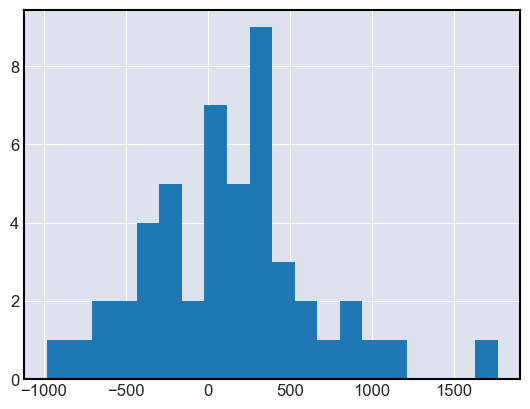

In [24]:
# Calculate summary of trades

n_win_trades = float(df_trade[df_trade['pnl']>0.0]['pnl'].count())
n_los_trades = float(df_trade[df_trade['pnl']<0.0]['pnl'].count())
print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])
print("Number Winning Trades : %d" % n_win_trades)
print("Number Losing Trades  : %d" % n_los_trades)
print("Percent Profitable    : %.2f%%" % (100*n_win_trades/(n_win_trades + n_los_trades)))
print("Avg Win Trade         : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].mean())
print("Avg Los Trade         : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].mean())
print("Largest Win Trade     : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].max())
print("Largest Los Trade     : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].min())
print("Profit Factor         : %.2f" % abs(df_trade[df_trade['pnl']>0.0]['pnl'].sum()/df_trade[df_trade['pnl']<0.0]['pnl'].sum()))

df_trade['pnl'].hist(bins=20)

In [25]:
df_trade.head()

,return,label,pred,won,pnl,equity
0,0.007989,1.0,1.0,True,798.863903,798.863903
1,-0.007450,0.0,1.0,False,-745.006196,53.857706
2,-0.002810,0.0,0.0,True,281.030252,334.887958
3,-0.000279,0.0,1.0,False,-27.907298,306.980661
4,-0.000201,0.0,0.0,True,20.086257,327.066917


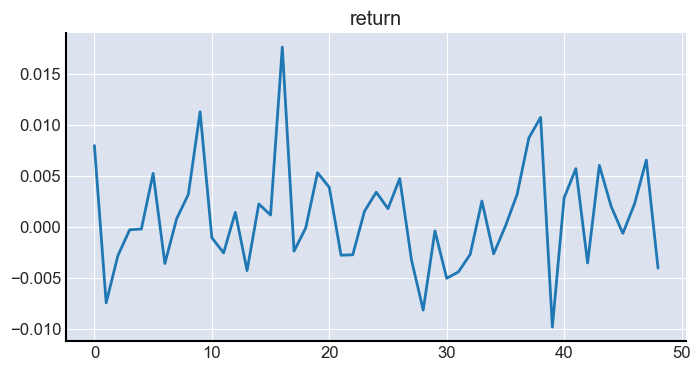

In [26]:
# @title return

from matplotlib import pyplot as plt
df_trade['return'].plot(kind='line', figsize=(8, 4), title='return')
plt.gca().spines[['top', 'right']].set_visible(False)

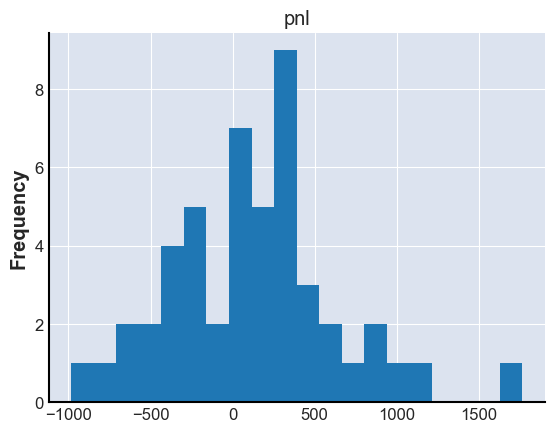

In [27]:
# @title pnl

from matplotlib import pyplot as plt
df_trade['pnl'].plot(kind='hist', bins=20, title='pnl')
plt.gca().spines[['top', 'right',]].set_visible(False)

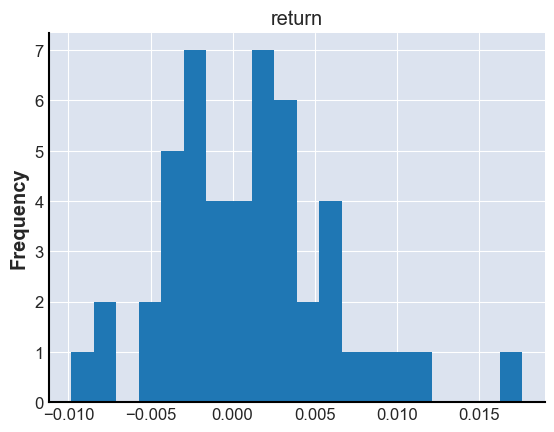

In [28]:
# @title return

from matplotlib import pyplot as plt
df_trade['return'].plot(kind='hist', bins=20, title='return')
plt.gca().spines[['top', 'right',]].set_visible(False)

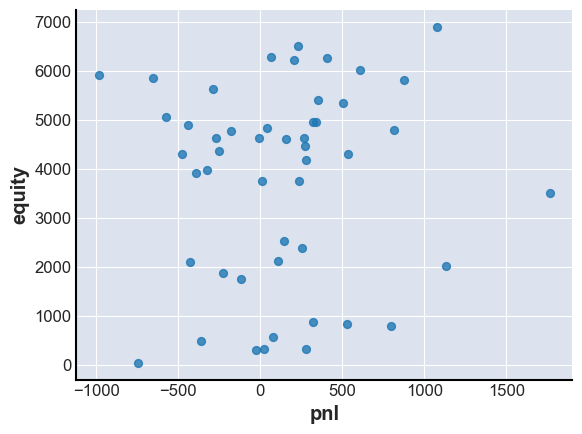

In [29]:
# @title pnl vs equity

from matplotlib import pyplot as plt
df_trade.plot(kind='scatter', x='pnl', y='equity', s=32, alpha=.8)
plt.gca().spines[['top', 'right',]].set_visible(False)

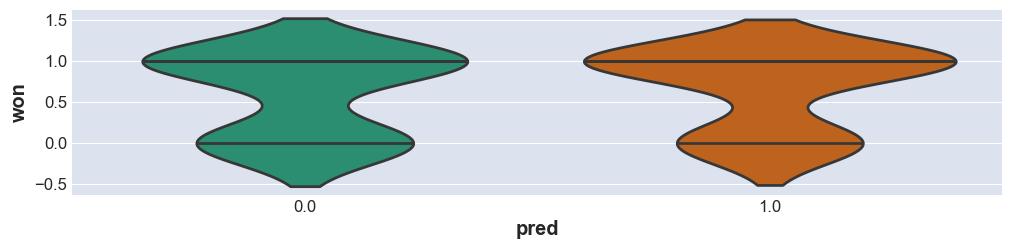

In [30]:
# @title won vs pred

from matplotlib import pyplot as plt
import seaborn as sns
figsize = (12, 1.2 * len(df_trade['won'].unique()))
plt.figure(figsize=figsize)
sns.violinplot(df_trade, x='pred', y='won', inner='stick', palette='Dark2')
sns.despine(top=True, right=True, bottom=True, left=True)

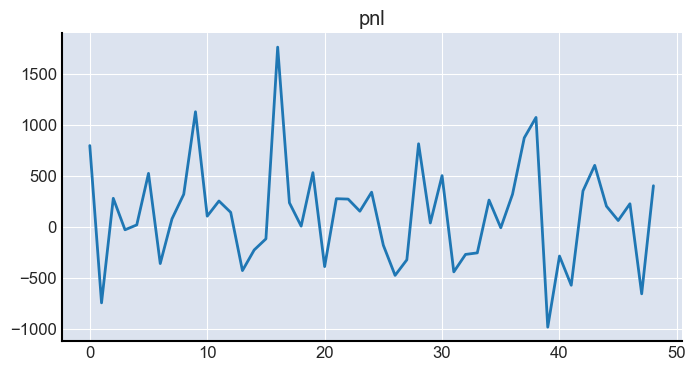

In [31]:
# @title pnl

from matplotlib import pyplot as plt
df_trade['pnl'].plot(kind='line', figsize=(8, 4), title='pnl')
plt.gca().spines[['top', 'right']].set_visible(False)

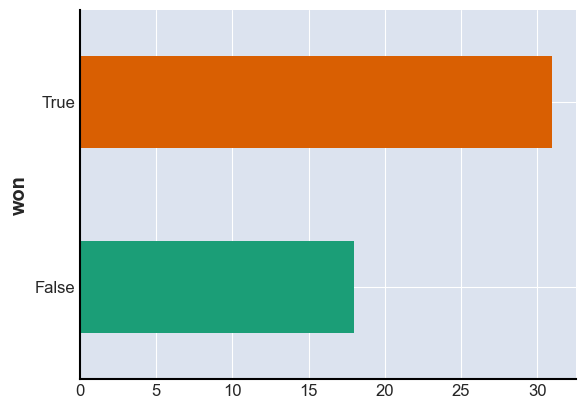

In [32]:
# @title won

from matplotlib import pyplot as plt
import seaborn as sns
df_trade.groupby('won').size().plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))
plt.gca().spines[['top', 'right',]].set_visible(False)

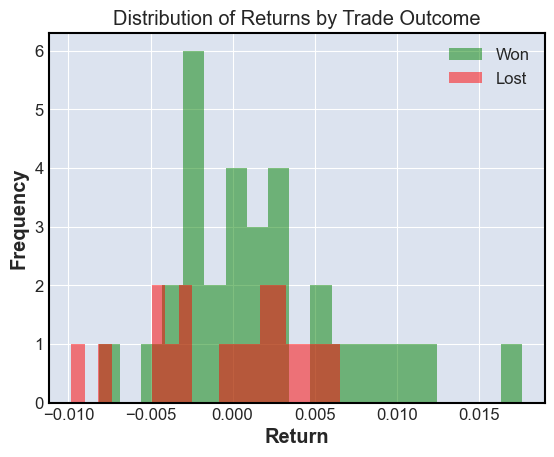

In [33]:
# @title Distribution of Returns by Trade Outcome

import matplotlib.pyplot as plt

plt.hist(df_trade[df_trade['won'] == True]['return'], bins=20, alpha=0.5, label='Won', color='green')
plt.hist(df_trade[df_trade['won'] == False]['return'], bins=20, alpha=0.5, label='Lost', color='red')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.title('Distribution of Returns by Trade Outcome')
_ = plt.legend()

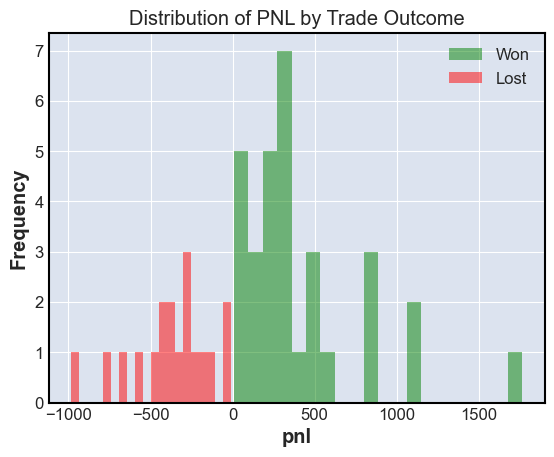

In [34]:
# @title Distribution of Returns by Trade Outcome

import matplotlib.pyplot as plt

plt.hist(df_trade[df_trade['won'] == True]['pnl'], bins=20, alpha=0.5, label='Won', color='green')
plt.hist(df_trade[df_trade['won'] == False]['pnl'], bins=20, alpha=0.5, label='Lost', color='red')
plt.xlabel('pnl')
plt.ylabel('Frequency')
plt.title('Distribution of PNL by Trade Outcome')
_ = plt.legend()

In [29]:
import logging
from telegram import Update, InputFile
from telegram.ext import ApplicationBuilder, CommandHandler, CallbackContext
from telegram import Update

# Enable logging
logging.basicConfig(
    format='%(asctime)s - %(name)s - %(levelname)s - %(message)s', level=logging.INFO
)
logger = logging.getLogger(__name__)

# Define the start command handler
def start(update: Update, context: CallbackContext) -> None:
    update.message.reply_text('Hi! Use /sendimage to receive an image and /senddoc to receive a document.')

# Define the send image handler
def send_image(update: Update, context: CallbackContext) -> None:
    chat_id = update.message.chat_id
    # Path to your image file
    image_path = 'path_to_your_image.jpg'
    context.bot.send_photo(chat_id=chat_id, photo=open(image_path, 'rb'))

# Define the send document handler
def send_document(update: Update, context: CallbackContext) -> None:
    chat_id = update.message.chat_id
    # Path to your document file
    document_path = 'output.csv'
    context.bot.send_document(chat_id=chat_id, document=open(document_path, 'rb'))

# Define the main function to start the bot
def main():
    # Your bot's token obtained from BotFather
    TOKEN = '7960242594:AAETVcblagcf39yEI2VXLkUggcGmWaROS50'

    app = ApplicationBuilder().token(TOKEN).build()

    # Register the command handlers
    app.add_handler(CommandHandler("start", start))
    app.add_handler(CommandHandler("sendimage", send_image))
    app.add_handler(CommandHandler("senddoc", send_document))

    # Start the Bot
    app.run_polling()

    # Run the bot until you press Ctrl-C or the process receives SIGINT, SIGTERM or SIGABRT
  

In [30]:
main()

RuntimeError: Cannot close a running event loop

In [35]:
from joblib import dump, load

# Save the model to a file
dump(model, 'neon.joblib')


['neon.joblib']

,return,label,pred,won,Date,pnl,equity
44,0.002039,1.0,1.0,True,NaT,203.887678,6220.576093
45,-0.000632,0.0,0.0,True,NaT,63.187042,6283.763135
46,0.002276,1.0,1.0,True,NaT,227.570194,6511.333329
47,0.006563,1.0,0.0,False,NaT,-656.299119,5855.034210
48,-0.004045,0.0,0.0,True,NaT,404.513678,6259.547888


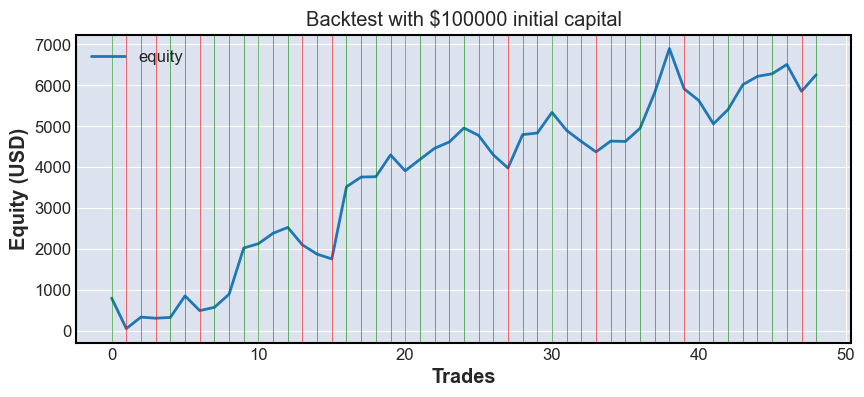

In [36]:
# Load the model from the file
loaded_model = load('model.joblib')

# Make predictions with the loaded model
predictions = loaded_model.predict(train_x[train_len:])
# Calculate equity..

contracts  = 100000.0
commission = 0.0


df_trade = pd.DataFrame(train_x[train_len:,-1], columns=['return'])
df_trade['label']  = train_y[train_len:]
df_trade['pred']   = pred
df_trade['won']    = df_trade['label'] == df_trade['pred']
df_trade['Date'] = df['Date'][train_len:]
df_trade['return'] = df_trade['return'].shift(-1) * return_range
df_trade.drop(df_trade.index[len(df_trade)-1], inplace=True)

def calc_profit(row):
    if row['won']:
        return abs(row['return'])*contracts - commission
    else:
        return -abs(row['return'])*contracts - commission

df_trade['pnl'] = df_trade.apply(lambda row: calc_profit(row), axis=1)
df_trade['equity'] = df_trade['pnl'].cumsum()

display(df_trade.tail())
df_trade.plot(y='equity', figsize=(10,4), title='Backtest with $100000 initial capital')
plt.xlabel('Trades')
plt.ylabel('Equity (USD)')
for r in df_trade.iterrows():
    if r[1]['won']:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='g')
    else:
        plt.axvline(x=r[0], linewidth=0.5, alpha=0.8, color='r')


In [37]:
df_trade['risk'] = df_trade['return'] * 1000

Net Profit            : $6259.55
Risk Exposure         : 47
Total win volume      : 13000
Total loss volume     : -6740
Number Winning Trades : 31
Number Losing Trades  : 18
Percent Profitable    : 63.27%
Avg Win Trade         : $419.361
Avg Los Trade         : $-374.480
Largest Win Trade     : $1764.890
Largest Los Trade     : $-983.379
Profit Factor         : 1.93


C:\Users\ADMIN\AppData\Local\Temp\ipykernel_18548\1941190366.py:7: FutureWarning: Calling float on a single element Series is deprecated and will raise a TypeError in the future. Use float(ser.iloc[0]) instead
  print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])


<Axes: >

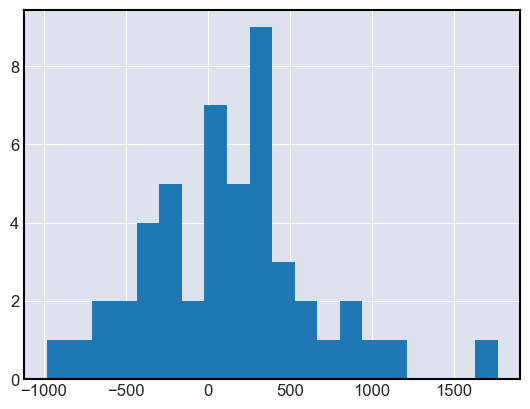

In [38]:
# Calculate summary of trades
n_win_trades = float(df_trade[df_trade['pnl']>0.0]['pnl'].count())
n_los_trades = float(df_trade[df_trade['pnl']<0.0]['pnl'].count())
win_vol = df_trade[df_trade['pnl']>0.0]['pnl'].mean() * n_win_trades
loss_vol = df_trade[df_trade['pnl']<0.0]['pnl'].mean() * n_los_trades
risk_exposure = df_trade['risk'].sum()
print("Net Profit            : $%.2f" % df_trade.tail(1)['equity'])
print("Risk Exposure         : %d" % risk_exposure)
print("Total win volume      : %d" % win_vol)
print("Total loss volume     : %d" % loss_vol)
print("Number Winning Trades : %d" % n_win_trades)
print("Number Losing Trades  : %d" % n_los_trades)
print("Percent Profitable    : %.2f%%" % (100*n_win_trades/(n_win_trades + n_los_trades)))
print("Avg Win Trade         : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].mean())
print("Avg Los Trade         : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].mean())
print("Largest Win Trade     : $%.3f" % df_trade[df_trade['pnl']>0.0]['pnl'].max())
print("Largest Los Trade     : $%.3f" % df_trade[df_trade['pnl']<0.0]['pnl'].min())
print("Profit Factor         : %.2f" % abs(df_trade[df_trade['pnl']>0.0]['pnl'].sum()/df_trade[df_trade['pnl']<0.0]['pnl'].sum()))

df_trade['pnl'].hist(bins=20)

In [39]:
df_trade.head()

,return,label,pred,won,Date,pnl,equity,risk
0,0.007989,1.0,1.0,True,NaT,798.863903,798.863903,7.988639
1,-0.007450,0.0,1.0,False,NaT,-745.006196,53.857706,-7.450062
2,-0.002810,0.0,0.0,True,NaT,281.030252,334.887958,-2.810303
3,-0.000279,0.0,1.0,False,NaT,-27.907298,306.980661,-0.279073
4,-0.000201,0.0,0.0,True,NaT,20.086257,327.066917,-0.200863


In [40]:
df_trade.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   return  49 non-null     float64       
 1   label   49 non-null     float64       
 2   pred    49 non-null     float64       
 3   won     49 non-null     bool          
 4   Date    0 non-null      datetime64[ns]
 5   pnl     49 non-null     float64       
 6   equity  49 non-null     float64       
 7   risk    49 non-null     float64       
dtypes: bool(1), datetime64[ns](1), float64(6)
memory usage: 2.9 KB


In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1042 entries, 1 to 1042
Data columns (total 9 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1042 non-null   datetime64[ns]
 1   Open       1042 non-null   float64       
 2   High       1042 non-null   float64       
 3   Low        1042 non-null   float64       
 4   Close      1042 non-null   float64       
 5   Adj Close  1042 non-null   float64       
 6   Volume     1042 non-null   int64         
 7   return     1042 non-null   float64       
 8   label      1042 non-null   int64         
dtypes: datetime64[ns](1), float64(6), int64(2)
memory usage: 113.7 KB


In [42]:
df.head()

,Date,Open,High,Low,Close,Adj Close,Volume,return,label
1,2020-01-02,1.121894,1.116682,1.122712,1.122083,1.122083,0,0.000000,0
2,2020-01-03,1.117081,1.112570,1.118068,1.117144,1.117144,0,-0.102173,0
3,2020-01-06,1.116246,1.115810,1.120825,1.116196,1.116196,0,-0.019606,1
4,2020-01-07,1.119583,1.113487,1.119946,1.119800,1.119800,0,0.074548,0
5,2020-01-08,1.115573,1.111086,1.116520,1.115474,1.115474,0,-0.089488,0


In [46]:
# train_y.head()